# 05 — Member-lepton isolation: can it support a tighter working point?

The jet-based LJ isolation depends on an AK4 jet (pT > 15 GeV) lying within
ΔR < 0.4 of the lepton jet; when none does, the processor silently records
isolation = 0 — a *sentinel* value that looks perfectly isolated. At a **tight**
isolation working point these sentinels dominate the surviving background (real
background is cut away while the fake-zeros stay), which is what broke the
incumbent plane at its nominal boundaries. Notebook 04 escaped this not by
changing the isolation variable but by **anchoring the signal region at a loose
working point (muiso < 0.5)**, where — as this notebook confirms below — the
jet-iso sentinel is a negligible 0.1% of the region. The open question this
notebook asks is different: could a jet-match-free isolation let us move *back* to
a tighter, higher-purity working point without reintroducing a sentinel problem?

The candidate is **member isolation**. The ntuples carry per-lepton PF isolation
(`Muon_pfRelIso03_all`, `Electron/Photon_pfRelIso03_all`) — the scalar-pT sum of
other particle-flow candidates in a ΔR = 0.3 cone around the lepton, over the
lepton pT: ≈ 0 for a lonely lepton, order 1 for a lepton inside a jet. The
LJ-level member isolation is the worst (largest) per-lepton value among the LJ's
constituents (one jet-like member is enough to mark the LJ background-like), and
it needs no jet match. Its blind spot: DSA muons — the muon-system-only
reconstruction recovering muons born too far from the beamline for inner tracking
— carry no isolation branches, so a **DSA-only mu-LJ takes its own sentinel**
(−0.01). This is a physically meaningful class (genuinely displaced) rather than a
jet-threshold artifact, but it is still a sentinel. The sections below measure,
head to head, whether member isolation actually improves on the jet-based
definition: distributions, the sentinel rates *at the working point*, where the
jet no-match events land under member iso, signal/background discrimination (ROC),
factorization of member-iso planes, and the egm-side parity check. The verdict is
in the Findings — and it is not the optimistic one.

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

sys.path.insert(0, os.getcwd())
import abcd_tools as at
import study_setup as ss

import plot_helpers as ph

hep.style.use("CMS")
plt.rcParams["figure.figsize"] = (9, 7)
# even-parity half of the sample = half the effective luminosity
LUMI_LABEL = ph.LUMI_EVEN
cms_label = ph.cms_label

# pre-skim / pre-filter sums of gen weights (see README "Normalization")
SUMW_PRE = {}
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_SIGNAL_2MU2E))
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_SIGNAL_4MU))
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_BKG_UNSKIMMED))
SUMW_PRE.update(ss.SUMW_PRE_OVERRIDES)   # DY rogue-file repair (see study_setup)

# normalization tripwire: a factor outside [1e-5, 1] means a broken denominator
for _s in ss.ANALYSIS_BACKGROUNDS:
    _f = ss.fetch(_s)["metadata"]["scaled_sum_weights"] / SUMW_PRE[_s] / ss.FW.get(_s, 1.0)
    assert 1e-5 < _f <= 1.0, f"normalization factor out of range for {_s}: {_f:.3g}"

# Background sums built ONE SAMPLE AT A TIME (holding all 44 samples in memory OOMs
# the interactive node); signals are loaded lazily where needed, one at a time.
# TTJets kept at the campaign 471.7 pb; the NNLO alternative is an explicit rescale.
total_bkg, by_process = ss.accumulate_normalized(list(ss.ANALYSIS_BACKGROUNDS), SUMW_PRE)
def load_sig(s):
    return ss.load_normalized(s, SUMW_PRE)[0]
print(f"accumulated {len(ss.ANALYSIS_BACKGROUNDS)} background samples "
      f"(DYJetsToMuMu_M50 excluded); scan hists: {len(total_bkg)}")

# round-2 member campaign: identical normalization, second merged-output set
total_bkg_m, by_process_m = ss.accumulate_normalized(
    list(ss.ANALYSIS_BACKGROUNDS), SUMW_PRE, keep_prefix="abcd_",
    eos_dir=ss.EOS_MERGED_MEMBER, tag=".member")
def load_sig_m(s):
    return ss.load_normalized(s, SUMW_PRE, eos_dir=ss.EOS_MERGED_MEMBER, tag=".member")[0]
def member1d(hists, hname, ch, axname):
    hh = at.get_channel(hists[hname], ss.CHANNELS[ch])
    vals, var, xe, ye = at.project_plane(hh, axname, "parity", {})
    return vals[:, 0], xe   # even half
SIG_SHOW = {"2mu2e": ["2Mu2E_500GeV_1p2GeV_1p9mm", "2Mu2E_1000GeV_1p2GeV_0p96mm",
                      "2Mu2E_100GeV_1p2GeV_9p6mm"],
            "4mu": ["4Mu_500GeV_1p2GeV_1p9mm", "4Mu_1000GeV_1p2GeV_0p96mm",
                    "4Mu_100GeV_1p2GeV_9p6mm"]}
print(f"member campaign accumulated: {sorted(n for n in total_bkg_m)}")

accumulated 17 background samples (DYJetsToMuMu_M50 excluded); scan hists: 8


member campaign accumulated: ['abcd_cosmic_2mu2e', 'abcd_cosmic_4mu', 'abcd_member_2mu2e', 'abcd_member_4mu', 'abcd_mother_2mu2e', 'abcd_mother_4mu']


## Member-isolation distributions

Stacked backgrounds with signal overlays (even half, preselection). The gray band
is the no-constituent sentinel: for the mu side, DSA-only lepton jets.

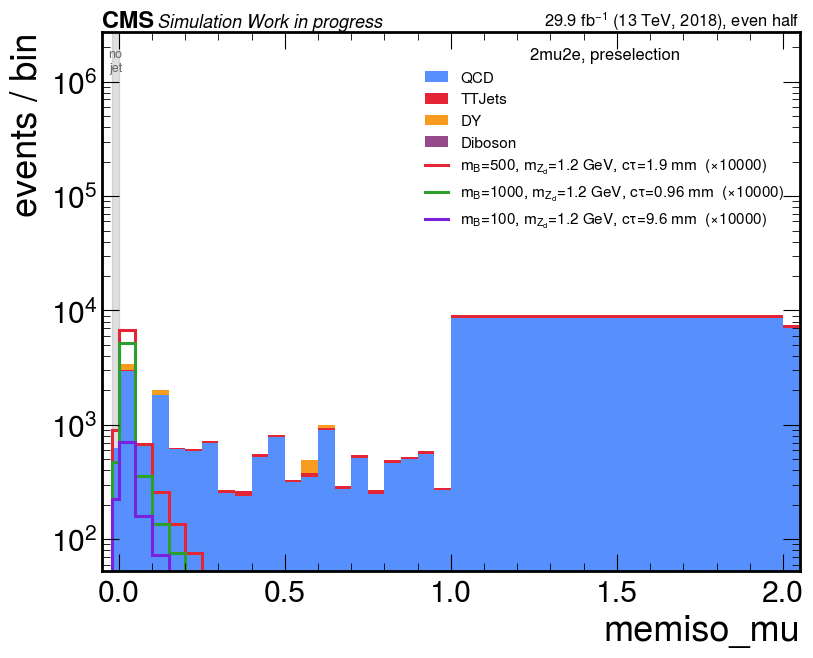

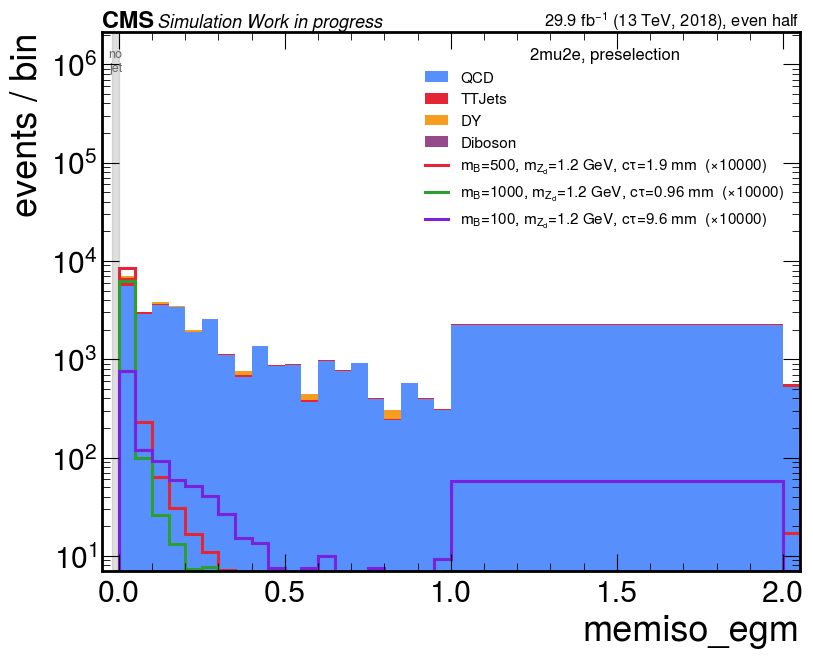

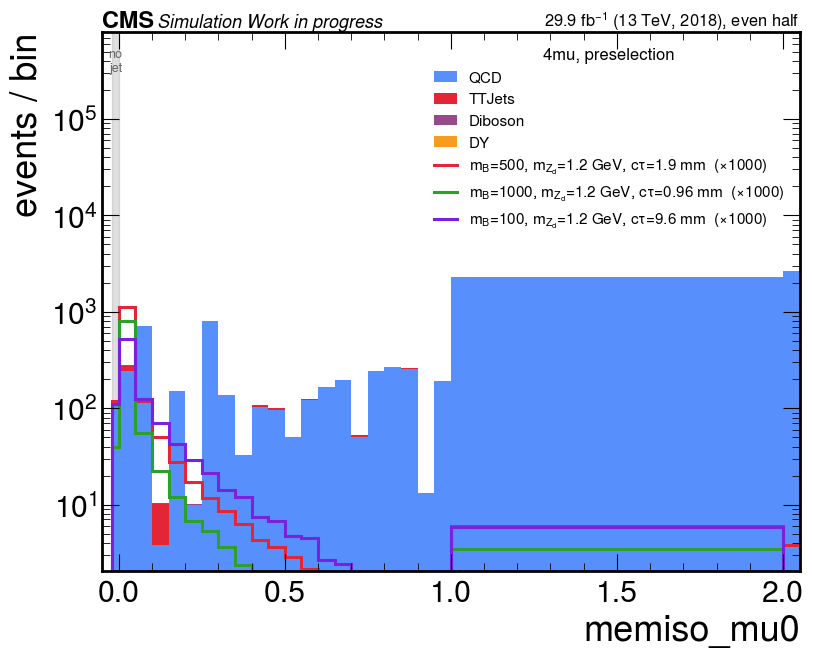

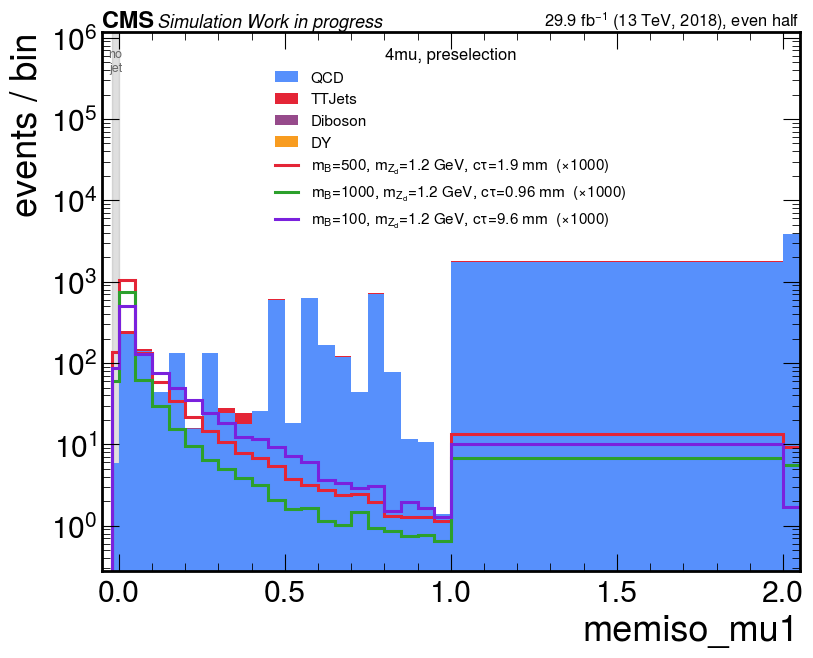

In [2]:
for ch, hname, axes in [("2mu2e", "abcd_member_2mu2e", ["memiso_mu", "memiso_egm"]),
                        ("4mu", "abcd_member_4mu", ["memiso_mu0", "memiso_mu1"])]:
    sig_axes = {}
    for sname in SIG_SHOW[ch]:
        sh = load_sig_m(sname)
        for axname in axes:
            sig_axes[(sname, axname)] = member1d(sh, hname, ch, axname)
        del sh
    for axname in axes:
        procs = []
        for pnm in ss.PROCESSES:
            v, xe = member1d(by_process_m[pnm], hname, ch, axname)
            procs.append((pnm, v))
        procs.sort(key=lambda t: -t[1].sum())
        smax = max(t[1].sum() for t in procs)
        sig_entries = []
        for sname in SIG_SHOW[ch]:
            v, sxe = sig_axes[(sname, axname)]
            if v.sum() <= 0:
                continue
            scale = 10 ** max(0, int(np.round(np.log10(smax / max(v.sum(), 1e-12) / 10))))
            sig_entries.append((sname, v, scale))
        ph.stack1d(procs, xe, xname=axname, signal_entries=sig_entries,
                   note=f"{ch}, preselection", ylabel="events / bin",
                   xlim=(-0.05, 2.05))

The x-axis is cropped to [−0.05, 2] to show the discriminating region; the
member-isolation axis has coarse overflow bins out to 1000 (a jet-like member can
carry many times the lepton pT) that would otherwise flatten the view. The leftmost
shaded bin is the DSA-only sentinel (no PF constituent to isolate).

## Where the jet no-match events go under member isolation

The migration matrix between the jet-based isolation (coarse: sentinel / pass WP /
fail WP) and member isolation (coarse: DSA-only sentinel / < 0.4 / 0.4–1 / ≥ 1),
row-normalized. Two things to read off it. First, for events **with** a PF muon
the two definitions agree: jet-iso-pass rows land at member iso < 0.4 and
jet-iso-fail rows at member iso ≥ 1 — member isolation is a valid isolation
measure. Second, and decisively, the **jet no-match** row does not migrate to a
real value at all: it lands ≈100% in the DSA-only member sentinel. The jet
no-match events are precisely the DSA-only lepton jets (a mu-LJ with a PF muon
always has nearby PF activity to seed a jet, so it always gets a match), so member
isolation does not rescue them — it **relabels** one sentinel as another. The
un-isolatable population is genuinely un-isolatable under either definition
because there is no PF muon to isolate.

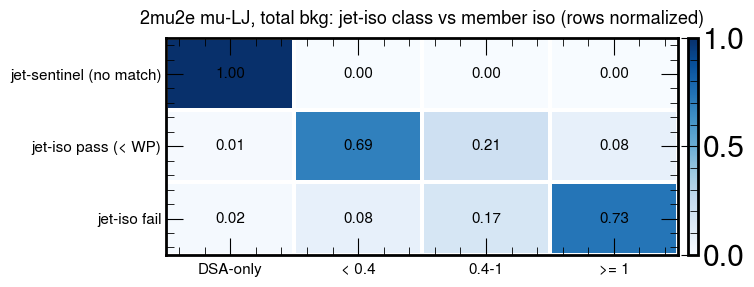

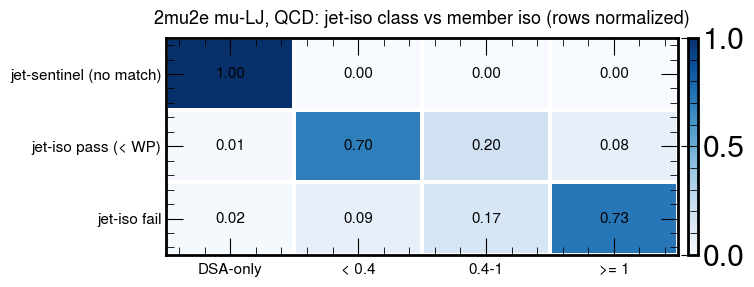

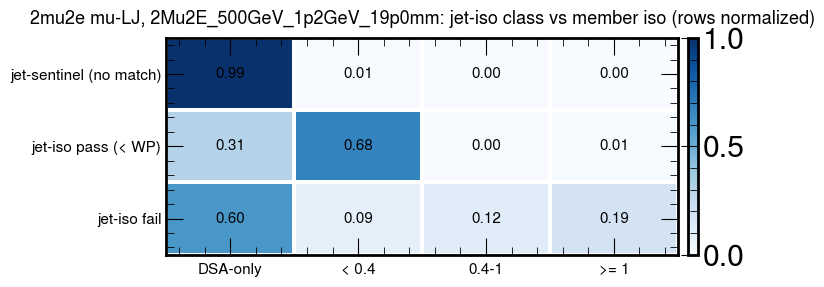

In [3]:
MEM_COARSE = [(-0.02, 0.0, "DSA-only"), (0.0, 0.4, "< 0.4"),
              (0.4, 1.0, "0.4-1"), (1.0, 1000.0, ">= 1")]
JET_ROWS = ["jet-sentinel (no match)", "jet-iso pass (< WP)", "jet-iso fail"]
for label, hists in [("total bkg", total_bkg_m), ("QCD", by_process_m["QCD"])] + [
        (sname, load_sig_m(sname)) for sname in ["2Mu2E_500GeV_1p2GeV_19p0mm"]]:
    hh = at.get_channel(hists["abcd_member_2mu2e"], ss.CHANNELS["2mu2e"])
    vals, var, xe, ye = at.project_plane(hh, "jetiso3_mu", "memiso_mu",
                                         {"parity": ("bin", 0)})
    cols = [(at.edge_index(ye, a), at.edge_index(ye, b)) for a, b, _ in MEM_COARSE]
    mat = np.array([[vals[r, a:b].sum() for a, b in cols] for r in range(3)])
    rowsum = mat.sum(axis=1, keepdims=True)
    frac = np.where(rowsum > 0, mat / np.maximum(rowsum, 1e-300), np.nan)
    ph.matrix_heatmap(frac, JET_ROWS, [c[2] for c in MEM_COARSE],
                      f"2mu2e mu-LJ, {label}: jet-iso class vs member iso "
                      f"(rows normalized)", cmap="Blues", vmin=0, vmax=1,
                      fmt="{:.2f}")

## Sentinel rates: DSA-only (member) vs failed-jet-match

The two definitions' blind spots, side by side. Two comparisons matter: the
preselection marginal rate (first block below), and — the one that actually counts
— the sentinel fraction *inside the signal-region working point* (muiso < 0.5,
mJJ ≥ 50), where a sentinel that survives the cut contaminates the region. The
signal-vs-lifetime curves show that each definition's sentinel tracks genuine
displacement for signal (both rise with cτ).

total bkg    preselection: jet-no-match   0.09%   DSA-only(member)   1.78%
QCD          preselection: jet-no-match   0.10%   DSA-only(member)   1.91%
DY           preselection: jet-no-match   0.00%   DSA-only(member)   0.00%
TTJets       preselection: jet-no-match   0.00%   DSA-only(member)   0.00%
Diboson      preselection: jet-no-match   0.00%   DSA-only(member)   0.00%

SR (iso<0.5, mJJ>=50): jet-iso sentinel frac 0.1% of Sw=3.394e+04  |  member-iso sentinel frac 5.8% of Sw=1.037e+04


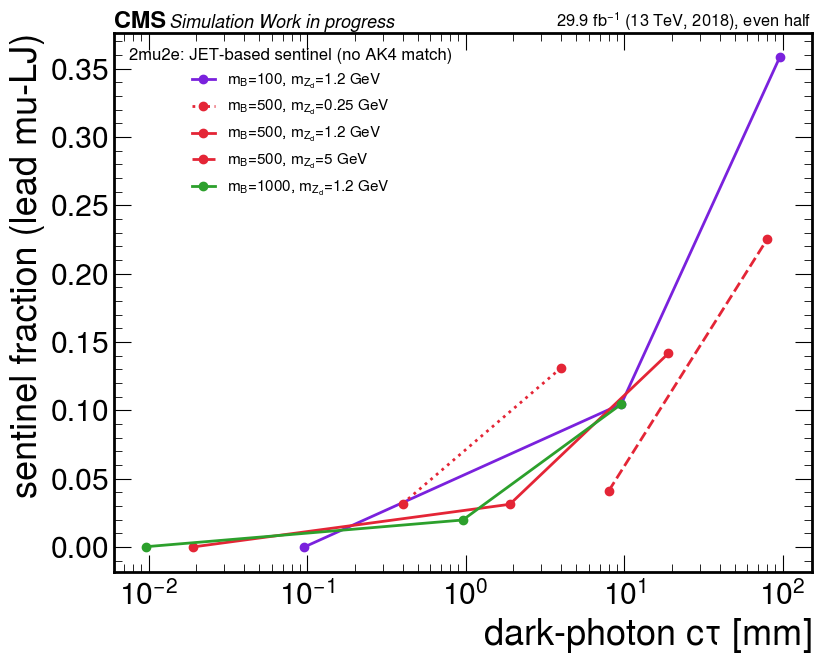

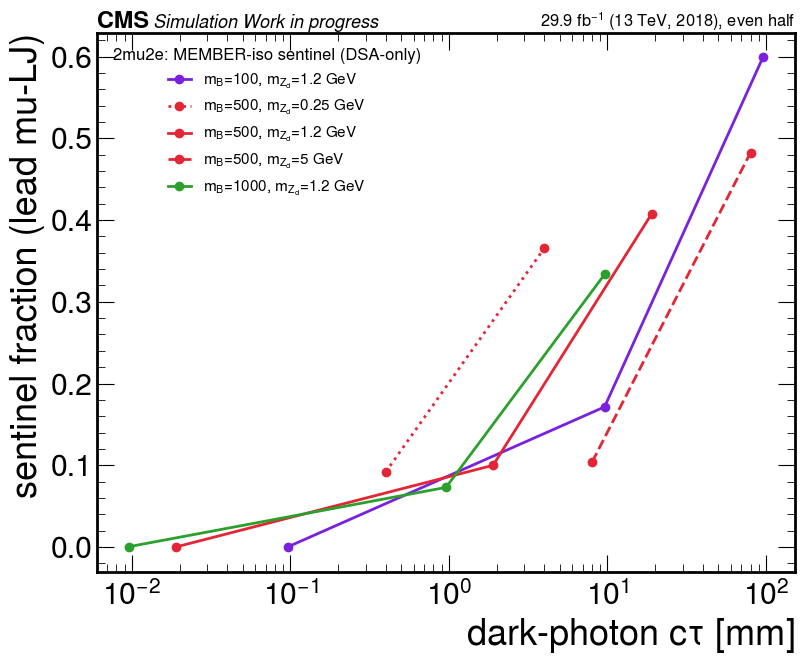

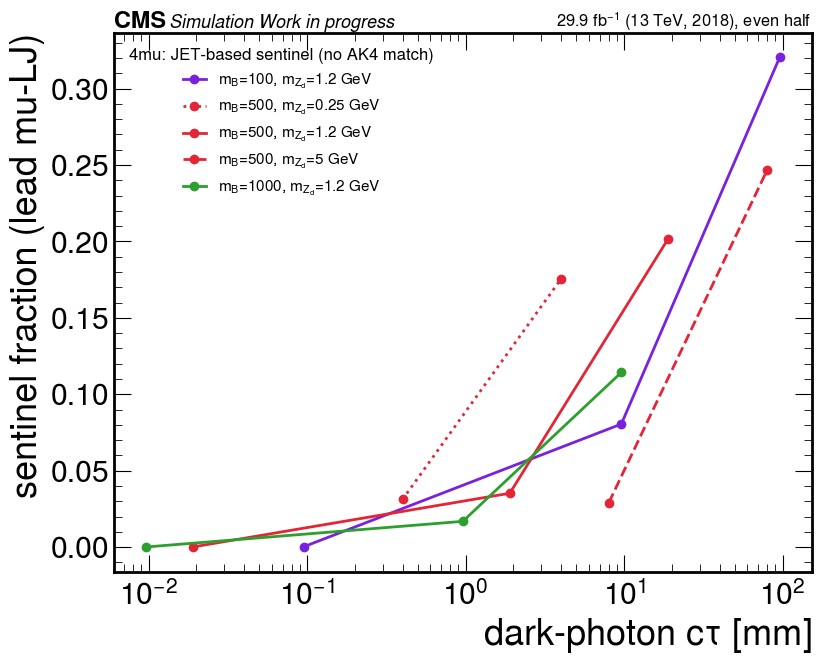

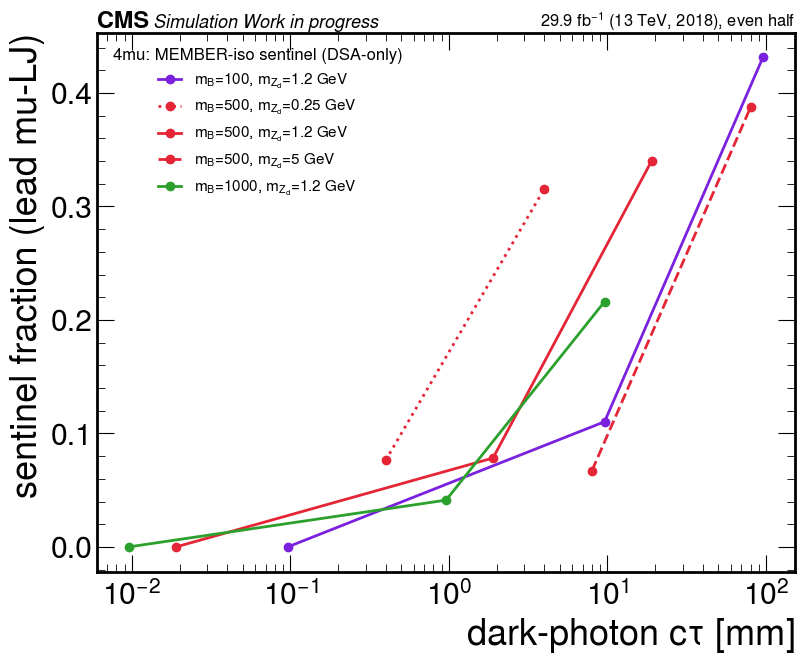

In [4]:
rates = {}
for label, hists in [("total bkg", total_bkg_m)] + [(pnm, by_process_m[pnm]) for pnm in ss.PROCESSES]:
    v, xe = member1d(hists, "abcd_member_2mu2e", "2mu2e", "memiso_mu")
    j, je = member1d(hists, "abcd_member_2mu2e", "2mu2e", "jetiso3_mu")
    if v.sum() > 0:
        rates[label] = (j[0] / j.sum(), v[0] / v.sum())
        print(f"{label:12s} preselection: jet-no-match {j[0]/j.sum():7.2%}   DSA-only(member) {v[0]/v.sum():7.2%}")
# The decisive number: sentinel fraction INSIDE the SR working point, both defs.
print()
hh = at.get_channel(total_bkg_m["abcd_member_2mu2e"], ss.CHANNELS["2mu2e"])
hf = hh[{"parity": 0}]
vv = hf.values()   # (memiso_mu, memiso_egm, jetiso3_mu, jetiso3_egm, mjj)
me, je, mje = hf.axes["memiso_mu"].edges, hf.axes["jetiso3_mu"].edges, hf.axes["mjj"].edges
hi = mje[:-1] >= 50.0
jt = (je[:-1] >= 0.0) & (je[:-1] < 0.5); js = je[:-1] < 0.0
mt = (me[:-1] >= 0.0) & (me[:-1] < 0.5); msn = me[:-1] < 0.0
jet_sr = vv[:, :, jt | js, :, :][:, :, :, :, hi].sum()
jet_sr_s = vv[:, :, js, :, :][:, :, :, :, hi].sum()
mem_sr = vv[mt | msn, :, :, :, :][:, :, :, :, hi].sum()
mem_sr_s = vv[msn, :, :, :, :][:, :, :, :, hi].sum()
print(f"SR (iso<0.5, mJJ>=50): jet-iso sentinel frac {jet_sr_s/max(jet_sr,1e-30):.1%} "
      f"of Sw={jet_sr:.4g}  |  member-iso sentinel frac {mem_sr_s/max(mem_sr,1e-30):.1%} "
      f"of Sw={mem_sr:.4g}")
mem_pts, jet_pts = {}, {}
for ch, hname, axname, sigs in [("2mu2e", "abcd_member_2mu2e", "memiso_mu", ss.SIGNALS_2MU2E),
                                ("4mu", "abcd_member_4mu", "memiso_mu0", ss.SIGNALS_4MU)]:
    mem_pts, jet_pts = {}, {}
    for sname in sigs:
        sh = load_sig_m(sname)
        v, xe = member1d(sh, hname, ch, axname)
        j, je = member1d(sh, hname, ch, "jetiso3_mu" if ch == "2mu2e" else "jetiso3_mu0")
        if v.sum() > 0:
            mem_pts[sname] = v[0] / v.sum()
            jet_pts[sname] = j[0] / j.sum()
        del sh
    ph.eff_vs_ctau(jet_pts, ylabel="sentinel fraction (lead mu-LJ)",
                   note=f"{ch}: JET-based sentinel (no AK4 match)", ylog=False)
    ph.eff_vs_ctau(mem_pts, ylabel="sentinel fraction (lead mu-LJ)",
                   note=f"{ch}: MEMBER-iso sentinel (DSA-only)", ylog=False)

## Discrimination: background rejection vs signal efficiency

Cumulative-cut curves from the same events (presel, even half): signal efficiency
vs background efficiency as the isolation cut tightens, member vs jet-based
definition. Sentinel bins are counted as passing (both definitions' current
behavior). Lower-left is better.

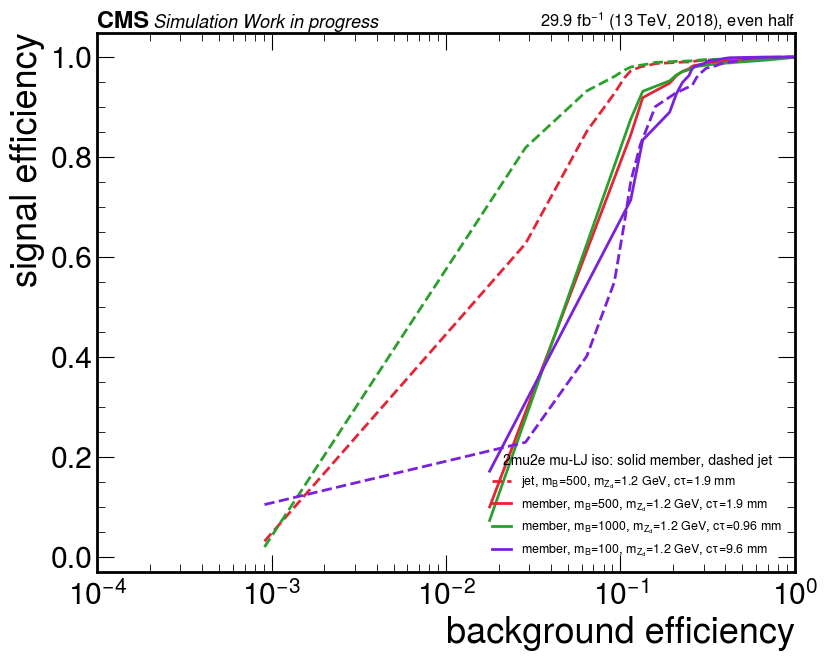

In [5]:
h1 = at.get_channel(total_bkg["abcd_scan_2mu2e_iso_iso"], ss.CHANNELS["2mu2e"])
jet_b = at.project_plane(h1, "muiso", "parity", {})[0][:, 0]
mem_b, mxe = member1d(total_bkg_m, "abcd_member_2mu2e", "2mu2e", "memiso_mu")
fig, axx = plt.subplots()
for sname in SIG_SHOW["2mu2e"]:
    sh = load_sig_m(sname)
    mem_s, _ = member1d(sh, "abcd_member_2mu2e", "2mu2e", "memiso_mu")
    del sh
    sh = load_sig(sname)
    hs = at.get_channel(sh["abcd_scan_2mu2e_iso_iso"], ss.CHANNELS["2mu2e"])
    jet_s = at.project_plane(hs, "muiso", "parity", {})[0][:, 0]
    del sh
    if mem_s.sum() <= 0 or jet_s.sum() <= 0:
        continue
    mB = ph.parse_sig(sname)[0]
    for bvals, svals, style, lab in [(jet_b, jet_s, "--", "jet"),
                                     (mem_b, mem_s, "-", "member")]:
        eb = np.cumsum(bvals) / bvals.sum()
        es = np.cumsum(svals) / svals.sum()
        axx.plot(eb, es, style, color=ph.MASS_COLORS[mB], lw=2,
                 label=f"{lab}, {ph.sig_label(sname)}" if lab == "member" or mB == 500 else None)
axx.set_xlabel("background efficiency")
axx.set_ylabel("signal efficiency")
axx.set_xscale("log")
axx.set_xlim(1e-4, 1)
axx.legend(title="2mu2e mu-LJ iso: solid member, dashed jet", fontsize=9,
           title_fontsize=10, framealpha=0.85, loc="lower right")
cms_label(axx)
plt.show()

## Do member-isolation planes factorize?

The gate-1 test on the member-iso ABCD candidates (presel, even half; prescription
(i) sentinel included / (ii) sentinel events dropped), per process and total.

2mu2e/M1 memiso_mu x memiso_egm/i   QCD:  0.085 DY:    nan TTJets:    nan Diboson:    nan total:  0.022


2mu2e/M1 memiso_mu x memiso_egm/ii  QCD:  0.128 DY:    nan TTJets:  0.016 Diboson:    nan total:  0.000


2mu2e/M2 memiso_mu x mjj/i   QCD:  0.019 DY:    nan TTJets:  0.321 Diboson:    nan total:  0.000


2mu2e/M2 memiso_mu x mjj/ii  QCD:  0.023 DY:  0.418 TTJets:  0.597 Diboson:  0.021 total:  0.000


4mu/M3 memiso0 x memiso1/i   QCD:  0.000 DY:    nan TTJets:    nan Diboson:    nan total:  0.000


4mu/M3 memiso0 x memiso1/ii  QCD:  0.000 DY:    nan TTJets:  0.985 Diboson:    nan total:  0.000


4mu/M4 memiso0 x mjj/i   QCD:  0.847 DY:    nan TTJets:    nan Diboson:    nan total:  0.117


4mu/M4 memiso0 x mjj/ii  QCD:  0.083 DY:    nan TTJets:    nan Diboson:    nan total:  0.743


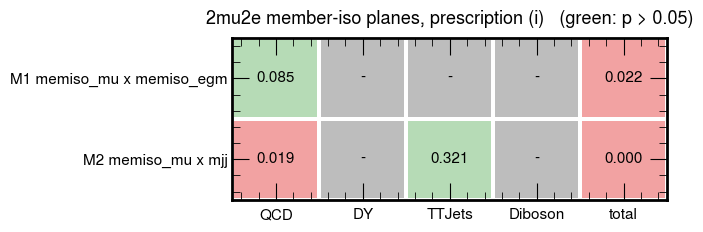

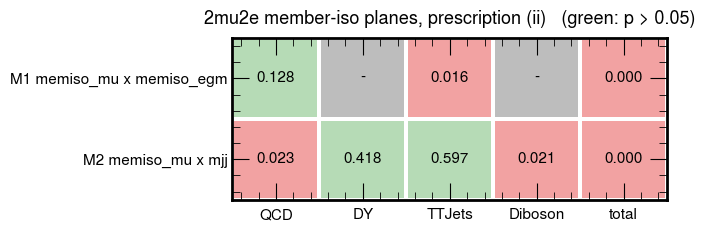

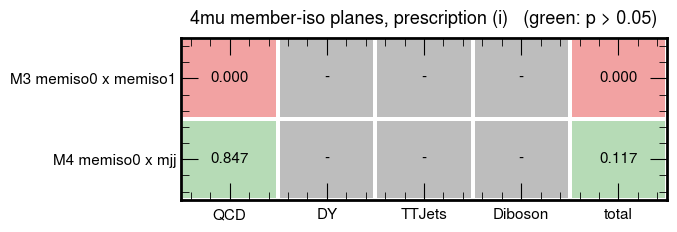

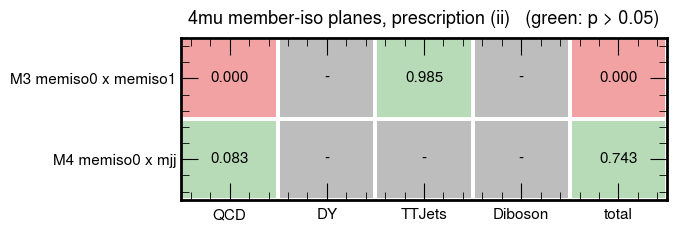

In [6]:
MPLANES = {
    "2mu2e": {"M1 memiso_mu x memiso_egm": ("abcd_member_2mu2e", "memiso_mu", "memiso_egm"),
              "M2 memiso_mu x mjj": ("abcd_member_2mu2e", "memiso_mu", "mjj")},
    "4mu": {"M3 memiso0 x memiso1": ("abcd_member_4mu", "memiso_mu0", "memiso_mu1"),
            "M4 memiso0 x mjj": ("abcd_member_4mu", "memiso_mu0", "mjj")},
}
mg1 = {}
for ch, planes in MPLANES.items():
    for pname, (hname, xa, ya) in planes.items():
        for presc in ("i", "ii"):
            ps = {}
            for pnm in list(ss.PROCESSES) + ["total"]:
                hset = total_bkg_m if pnm == "total" else by_process_m[pnm]
                if not hset:
                    ps[pnm] = np.nan
                    continue
                hh = at.get_channel(hset[hname], ss.CHANNELS[ch])
                vals, var, xe, ye = at.project_plane(hh, xa, ya, {"parity": ("bin", 0)})
                if presc == "ii":
                    if xe[0] < 0: vals, var, xe = vals[1:], var[1:], xe[1:]
                    if ye[0] < 0: vals, var, ye = vals[:, 1:], var[:, 1:], ye[1:]
                if vals.sum() <= 0:
                    ps[pnm] = np.nan
                    continue
                fit = at.factorization_fit(vals, var)
                ps[pnm] = fit["pvalue"]
            mg1[f"{ch}/{pname}/{presc}"] = ps
            show = " ".join(f"{k}:{v:7.3f}" for k, v in ps.items())
            print(f"{ch}/{pname}/{presc:2s}  {show}")
for ch in MPLANES:
    for presc in ("i", "ii"):
        rows = list(MPLANES[ch])
        cols = list(ss.PROCESSES) + ["total"]
        mat = [[mg1[f"{ch}/{r}/{presc}"].get(c, np.nan) for c in cols] for r in rows]
        ph.pvalue_heatmap(mat, rows, cols,
                          f"{ch} member-iso planes, prescription ({presc})")

## The egm side, for parity

Member isolation is buildable for egm lepton jets too (electron/photon
pfRelIso03_all), with one caveat the mu side does not have: the PF isolation sum
for electrons and photons includes photons in the cone, so the collimated partner
of an e/gamma constituent contributes to its isolation — a collimated SIGNAL egm
pair self-penalizes. The distributions above show it; the verdict below weighs it
against the jet-based definition, whose egm sentinel rate is already ~0.

In [7]:
v, xe = member1d(total_bkg_m, "abcd_member_2mu2e", "2mu2e", "memiso_egm")
print(f"egm member-iso sentinel (no e/gamma constituent) rate, total bkg: "
      f"{v[0]/v.sum():.2%} (should be ~0 by construction)")
for sname in SIG_SHOW["2mu2e"]:
    sh = load_sig_m(sname)
    v, xe = member1d(sh, "abcd_member_2mu2e", "2mu2e", "memiso_egm")
    if v.sum() > 0:
        med_bin = np.searchsorted(np.cumsum(v) / v.sum(), 0.5)
        print(f"{sname:34s} median member egm-iso bin edge ~ {xe[med_bin]:.2f}")
    del sh

egm member-iso sentinel (no e/gamma constituent) rate, total bkg: 0.00% (should be ~0 by construction)
2Mu2E_500GeV_1p2GeV_1p9mm          median member egm-iso bin edge ~ 0.00
2Mu2E_1000GeV_1p2GeV_0p96mm        median member egm-iso bin edge ~ 0.00
2Mu2E_100GeV_1p2GeV_9p6mm          median member egm-iso bin edge ~ 0.00


## Findings

Numbers are the even half on the **partial** member-campaign merge (2018 MC), with
no per-bin errors yet — treat the member-iso rates and p-values below as provisional
until the full merge.

**Member isolation does not improve on the jet-based definition for the 2mu2e
plane — it relabels the sentinel and factorizes worse.** The answer to the opening
question ("could a jet-match-free isolation support a tighter working point?") is
no, on four independent grounds:

1. **Sentinels are not solved, they are moved — and grow ~18×.** At the SR working
   point (muiso < 0.5, mJJ ≥ 50) the jet-based sentinel is a negligible 0.1% of the
   region — about 34 weighted events out of Σw≈34000 — whereas the member-iso
   sentinel is 5.8% (6.3% in QCD): about 600 weighted events out of the ≈10400 that
   survive the tighter member cut. (The two percentages are over different
   denominators — member-iso < 0.5 keeps far fewer events than jet-iso < 0.5 — so
   this is an expansion of the sentinel, not a like-for-like migration.) The
   migration matrix shows why: the jet no-match events land ≈100% in the DSA-only
   member sentinel — they are the same physical population (lepton jets with no PF
   muon), un-isolatable under either definition.
2. **Where both are defined, they broadly agree** (at the migration matrix's 0.4
   boundary, jet-iso-pass → member < 0.4 with 69%, jet-iso-fail → member ≥ 1 with
   73%), so member isolation is a valid isolation measure — though with ≈25–30%
   off-diagonal spread, not a tighter one. Note the migration bins split at 0.4
   while the SR uses 0.5.
3. **Worse discrimination.** The ROC curves have the jet-based definition
   dominating member isolation for every signal benchmark: at fixed background
   efficiency, jet isolation keeps more signal.
4. **Fails the independence gate for 2mu2e.** member-iso × mJJ fails factorization
   for total background (p ≈ 0.000 under both prescriptions), as does
   member-iso × member-iso: the same collimated-jet activity that raises a member's
   PF isolation also raises the dijet mass. The declared jet-based muiso × mJJ
   plane is retained.

**For 4mu the member-iso results are mixed and do not offer a tighter working
point either.** member-iso0 × member-iso1 is rejected (p = 0.000 / 0.000), while
member-iso0 × mJJ is *not rejected* — but only marginally in prescription i
(p = 0.117, against 0.743 in prescription ii), on partial even-half statistics, so
this is not a clean pass and should be re-checked with errors on the full merge. In
any case the jet-based plane is not in trouble for 4mu, so no member-iso result
enables the tighter, higher-purity working point the notebook set out to find.

**The one thing member isolation is good for is understanding the sentinel.** Its
DSA-only class is a clean, physically meaningful label (genuinely displaced,
no-PF-muon lepton jets, rising with cτ for signal) that notebook 06 uses to study
the sentinel population's gen origin and the cosmic-veto inputs. As an *ABCD axis*,
though, jet-based isolation with the loose (muiso < 0.5) anchor is both simpler and
better.

**egm parity: nothing to gain on the electron side.** egm-LJs always contain an
e/γ constituent, so the member-iso sentinel rate is ~0% by construction and there
is no no-match sentinel to solve; the jet-based egm treatment is retained.

*Partial-merge caveat:* 35 of 1699 chunks were unreadable during a transient EOS
storage-node outage; the merge normalizes by the Σw of included chunks, so these
fractions are unbiased in expectation (only lower effective stats, worst ≈86/98
chunks for one QCD bin). Numbers refresh automatically when the full merge
completes.